In [77]:
#importing liraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [78]:
#loading data set
df = pd.read_csv('/content/Airline_Delay_Cause.csv')

In [79]:
# After reloading, we need to drop nulls
df = df.dropna()
# Also, drop duplicates if any
df.drop_duplicates(inplace=True)

In [80]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            # Convert object columns to category if they have fewer than 50% unique values
            num_unique_values = len(df[col].unique())
            num_total_values = len(df[col])
            if num_unique_values / num_total_values < 0.5:
                df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {(100 * (start_mem - end_mem) / start_mem):.2f}%')

    return df

Now, let's apply this function to our DataFrame to optimize all data types.

In [81]:
# Apply the new memory reduction function to the DataFrame
df = reduce_mem_usage(df)

# Display info after reduction to see changes in dtypes and memory
df.info()

Memory usage of dataframe is 28.74 MB
Memory usage after optimization is: 9.01 MB
Decreased by 68.64%
<class 'pandas.core.frame.DataFrame'>
Index: 171223 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   year                 171223 non-null  int16   
 1   month                171223 non-null  int8    
 2   carrier              171223 non-null  category
 3   carrier_name         171223 non-null  category
 4   airport              171223 non-null  category
 5   airport_name         171223 non-null  category
 6   arr_flights          171223 non-null  float16 
 7   arr_del15            171223 non-null  float16 
 8   carrier_ct           171223 non-null  float16 
 9   weather_ct           171223 non-null  float16 
 10  nas_ct               171223 non-null  float16 
 11  security_ct          171223 non-null  float16 
 12  late_aircraft_ct     171223 non-null  float16 
 13  arr_can

/tmp/ipykernel_10914/3361089876.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_10914/3361089876.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_10914/3361089876.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_10914/3361089876.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:


In [82]:
#what is the shape
df.shape

(171223, 21)

In [83]:
df.sample()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
95260,2018,11,OH,PSA Airlines Inc.,IND,"Indianapolis, IN: Indianapolis International",110.0,20.0,8.273438,0.700195,...,0.0,7.941406,1.0,0.0,1810.0,816.0,75.0,121.0,0.0,798.0


In [84]:
#performing descriptive statitics
df.describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/na

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171223.000000,171223.000000,171223.0,171223.0,171223.000000,171223.000000,171223.000000,171223.0000,171223.000000,171223.0,171223.0,171223.000000,171223.000000,171223.0,171223.000000,171223.0,171223.000000
mean,2018.549739,6.495284,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,4244.514160,1438.889160,NaN,921.743103,NaN,1653.658447
std,2.891314,3.441753,0.0,0.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.0,0.0,12624.823242,4217.985352,0.0,3425.060547,0.0,5224.169922
min,2013.000000,1.000000,1.0,0.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000
25%,2016.000000,3.000000,50.0,6.0,2.169922,0.000000,1.000000,0.0000,1.240234,0.0,0.0,336.000000,111.000000,0.0,35.000000,0.0,66.000000
50%,2019.000000,7.000000,101.0,17.0,6.410156,0.399902,3.929688,0.0000,5.000000,1.0,0.0,1020.000000,375.000000,18.0,147.000000,0.0,321.000000
75%,2021.000000,9.000000,250.0,47.0,17.296875,1.860352,11.726562,0.0000,15.281250,4.0,1.0,2888.500000,1110.000000,146.0,478.000000,0.0,1072.000000
max,2023.000000,12.000000,21984.0,4176.0,1294.000000,266.500000,1884.000000,58.6875,2070.000000,4952.0,197.0,438783.000000,196944.000000,31968.0,112018.000000,3760.0,227959.000000


In [85]:
#knowing the data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171223 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   year                 171223 non-null  int16   
 1   month                171223 non-null  int8    
 2   carrier              171223 non-null  category
 3   carrier_name         171223 non-null  category
 4   airport              171223 non-null  category
 5   airport_name         171223 non-null  category
 6   arr_flights          171223 non-null  float16 
 7   arr_del15            171223 non-null  float16 
 8   carrier_ct           171223 non-null  float16 
 9   weather_ct           171223 non-null  float16 
 10  nas_ct               171223 non-null  float16 
 11  security_ct          171223 non-null  float16 
 12  late_aircraft_ct     171223 non-null  float16 
 13  arr_cancelled        171223 non-null  float16 
 14  arr_diverted         171223 non-null  float16 
 15  arr_d

In [86]:
df.isnull().sum()

,0
year,0
month,0
carrier,0
carrier_name,0
airport,0
airport_name,0
arr_flights,0
arr_del15,0
carrier_ct,0
weather_ct,0


In [88]:
df.shape

(171223, 21)

In [91]:
df.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

<Axes: xlabel='late_aircraft_delay', ylabel='Count'>

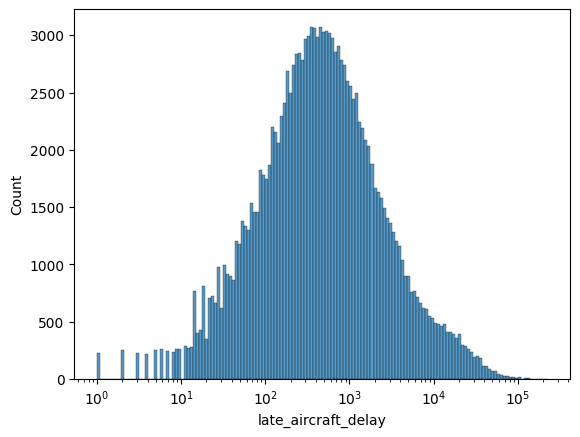

In [104]:
#now visualisation part
sns.histplot(data = df , x =df['late_aircraft_delay'] ,log_scale=True )

<Axes: xlabel='year', ylabel='late_aircraft_delay'>

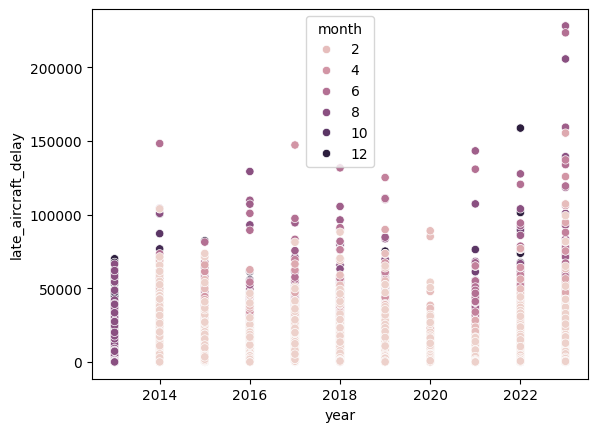

In [117]:
sns.scatterplot(data = df , x = df['year'] , y = df['late_aircraft_delay'] , hue=df['month'])

<Axes: ylabel='arr_cancelled'>

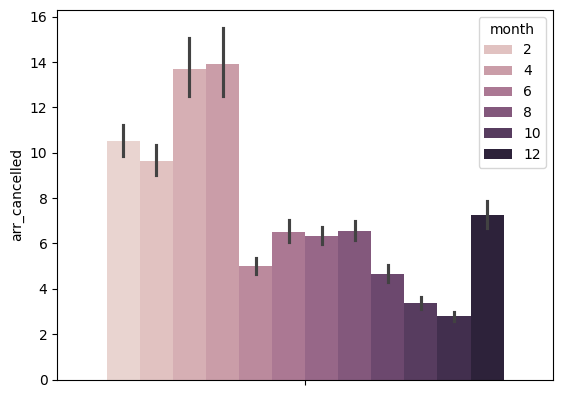

In [123]:
sns.barplot(df, y=df['arr_cancelled'] ,hue=df['month'] )

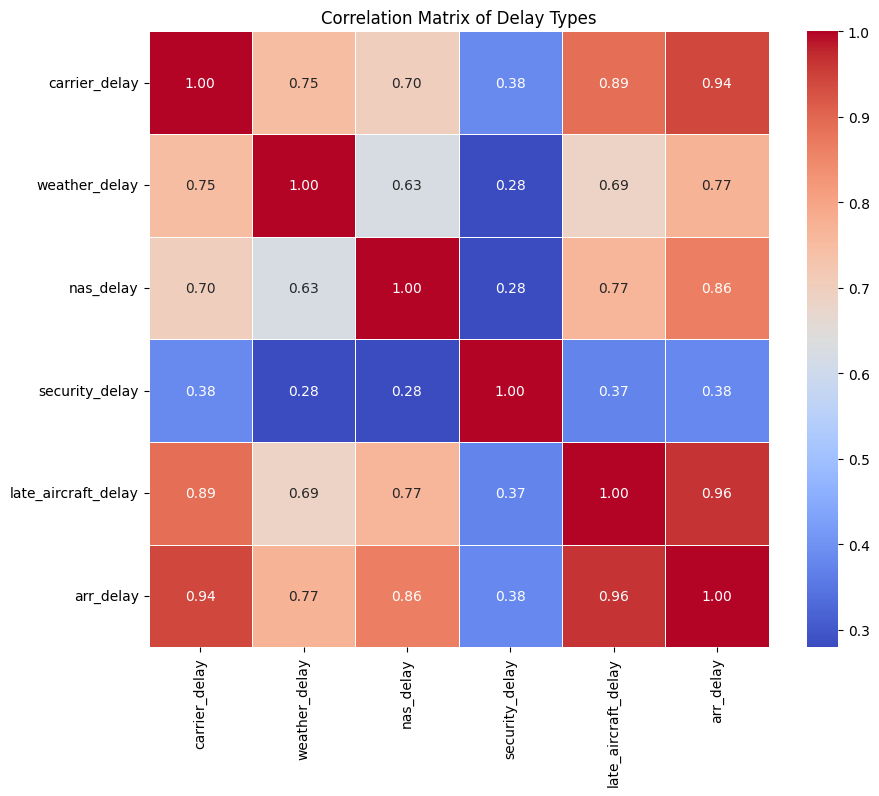

In [124]:
delay_columns = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'arr_delay']
correlation_matrix = df[delay_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Delay Types')
plt.show()

<Axes: >

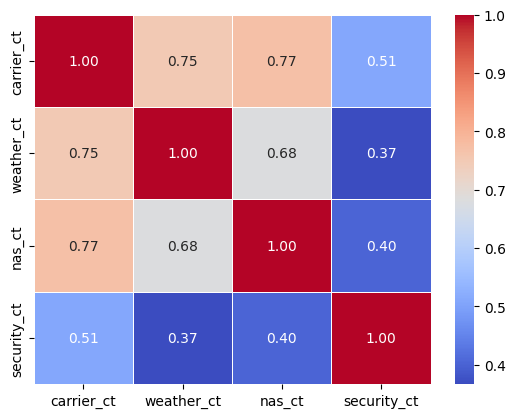

In [128]:
cat_column = ['carrier_ct', 'weather_ct', 'nas_ct','security_ct']
cat_matrix = df[cat_column].corr()

sns.heatmap(cat_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)


<Axes: xlabel='carrier_ct', ylabel='weather_ct'>

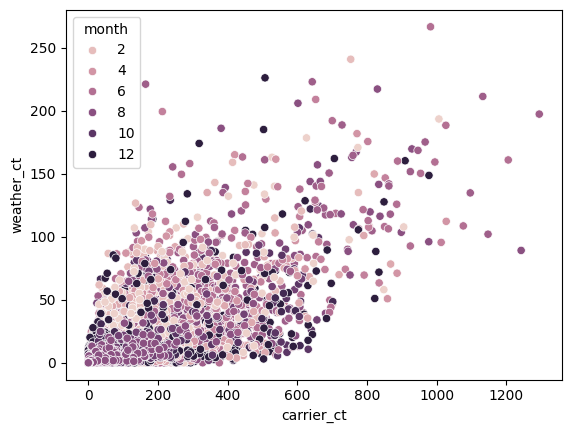

In [131]:
sns.scatterplot(df , x=df['carrier_ct'] , y =df['weather_ct'] , hue='month')

Here's a small summary of the visualizations performed so far:

Distribution of Late Aircraft Delay: A histogram was generated to show the distribution of late_aircraft_delay, indicating the frequency of different delay durations.
Yearly and Monthly Trends in Late Aircraft Delay: A scatterplot illustrated the relationship between the year and late_aircraft_delay, with month as a distinguishing factor, helping to identify any temporal patterns.
Monthly Breakdown of Canceled Flights: A bar plot displayed the total arr_cancelled (cancelled flights) by month, highlighting which months experience more cancellations.
Correlation of Delay Types: A heatmap of the delay_columns revealed strong correlations between arr_delay and late_aircraft_delay (0.96), and arr_delay and carrier_delay (0.91), while security_delay showed weaker correlations with other delay types.
Correlation of Delay Causes Counts: Another heatmap, focusing on carrier_ct, weather_ct, nas_ct, and security_ct, showed a notable positive correlation (0.75) between carrier_ct and weather_ct.
Interdependence of Carrier and Weather Delays: A scatterplot of carrier_ct vs. weather_ct, colored by month, visually confirmed the strong positive correlation observed in the heatmap, suggesting that as carrier-related delays increase, so do weather-related delays, potentially due to shared seasonal factors or cascading effects.

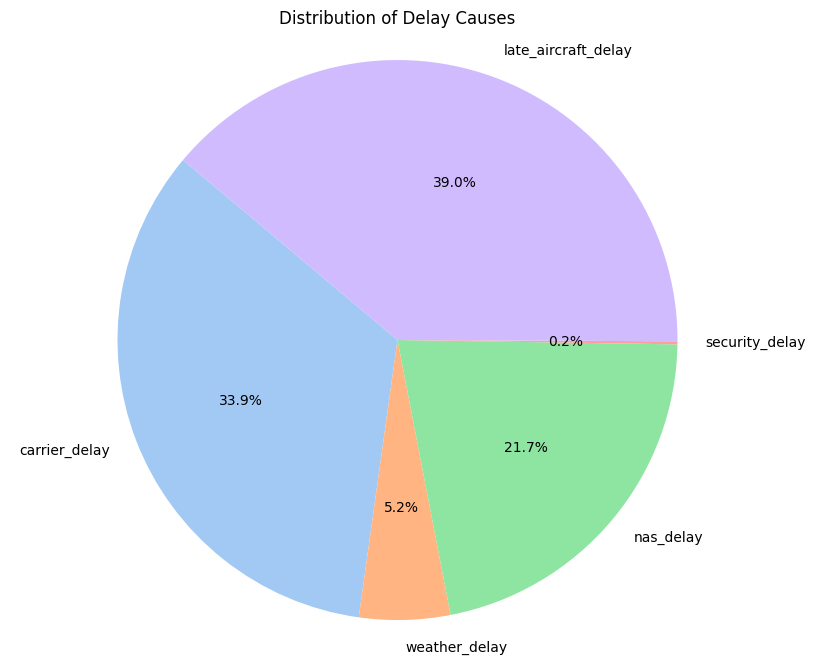

In [136]:
delay_type_columns = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

# Create a temporary DataFrame for these columns
df_temp = df[delay_type_columns].copy()

# Convert columns that are float16 to float32 to prevent overflow during sum
for col in delay_type_columns:
    if df_temp[col].dtype == np.float16:
        df_temp[col] = df_temp[col].astype(np.float32)

# Now, replace any potential inf values (if they still exist after type conversion or were present before) with NaN
df_temp.replace([np.inf, -np.inf], np.nan, inplace=True)

# Sum the columns and fill any resulting NaN sums with 0
delay_type_sums = df_temp.sum().fillna(0)

plt.figure(figsize=(10, 8))
plt.pie(delay_type_sums, labels=delay_type_sums.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Delay Causes')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This pie chart vividly illustrates the primary drivers of flight delays. We can clearly see which delay categories contribute the most to the overall accumulated delay time, offering insights into where mitigation efforts might be most effective. For example, if 'late_aircraft_delay' or 'carrier_delay' dominate, it points to operational or airline-specific issues.